In [1]:
import pandas as pd
import sqlite3

# Load the CSV from your USB drive
df = pd.read_csv("D:/Downloads/Sample - Superstore.csv", encoding="latin1")

# Preview the data
print(df.shape)
df.head()

(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
# Load into SQLite database
conn = sqlite3.connect("sales.db")
df.to_sql("orders", conn, if_exists="replace", index=False)

# Query: Total sales by Category
result = pd.read_sql_query("""
    SELECT Category, ROUND(SUM(Sales), 2) AS Total_Sales
    FROM orders
    GROUP BY Category
    ORDER BY Total_Sales DESC
""", conn)

print(result)

          Category  Total_Sales
0       Technology    836154.03
1        Furniture    741999.80
2  Office Supplies    719047.03


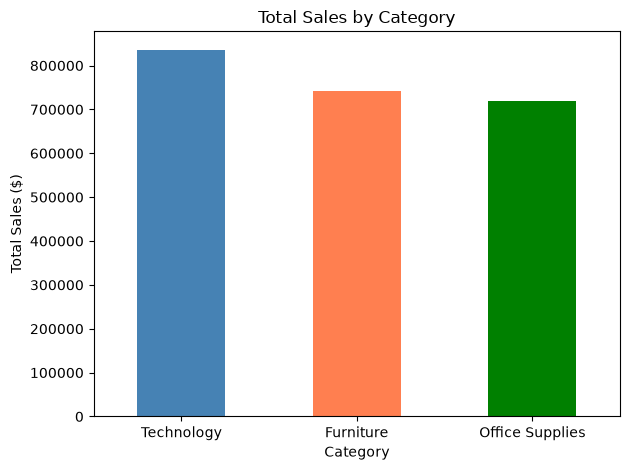

In [3]:
import matplotlib.pyplot as plt

result.plot(kind="bar", x="Category", y="Total_Sales", legend=False, color=["steelblue", "coral", "green"])
plt.title("Total Sales by Category")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [4]:
# Which region is most profitable?
region = pd.read_sql_query("""
    SELECT Region, ROUND(SUM(Profit), 2) AS Total_Profit
    FROM orders
    GROUP BY Region
    ORDER BY Total_Profit DESC
""", conn)

print(region)

    Region  Total_Profit
0     West     108418.45
1     East      91522.78
2    South      46749.43
3  Central      39706.36


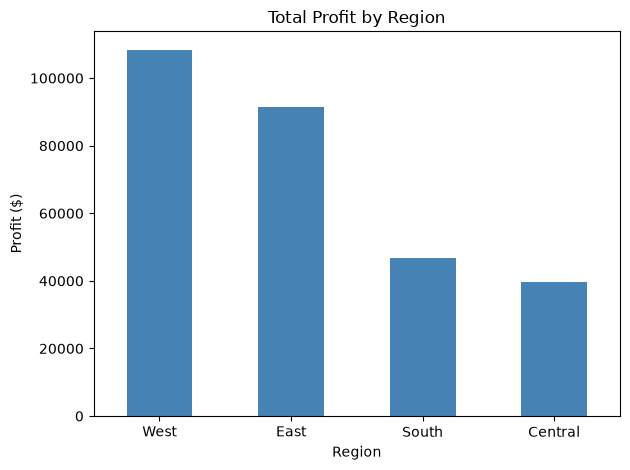

In [6]:
region = pd.read_sql_query("""
    SELECT Region, ROUND(SUM(Profit), 2) AS Total_Profit
    FROM orders
    GROUP BY Region
    ORDER BY Total_Profit DESC
""", conn)

region.plot(kind="bar", x="Region", y="Total_Profit", legend=False, color="steelblue")
plt.title("Total Profit by Region")
plt.ylabel("Profit ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

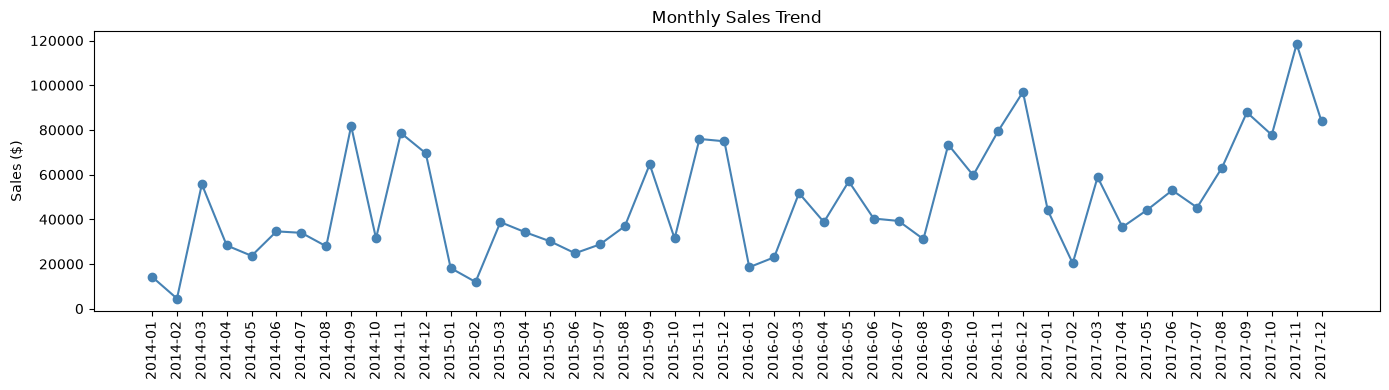

In [7]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Month"] = df["Order Date"].dt.to_period("M")

monthly = df.groupby("Month")["Sales"].sum().reset_index()
monthly["Month"] = monthly["Month"].astype(str)

plt.figure(figsize=(14, 4))
plt.plot(monthly["Month"], monthly["Sales"], marker="o", color="steelblue")
plt.title("Monthly Sales Trend")
plt.ylabel("Sales ($)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

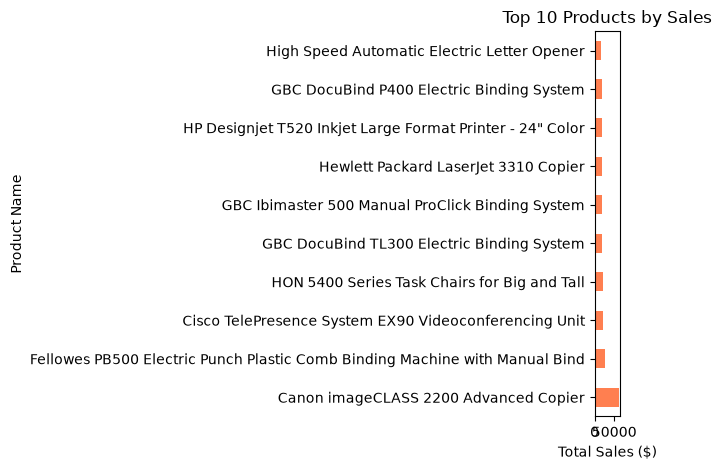

In [8]:
top_products = pd.read_sql_query("""
    SELECT "Product Name", ROUND(SUM(Sales), 2) AS Total_Sales
    FROM orders
    GROUP BY "Product Name"
    ORDER BY Total_Sales DESC
    LIMIT 10
""", conn)

top_products.plot(kind="barh", x="Product Name", y="Total_Sales", legend=False, color="coral")
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales ($)")
plt.tight_layout()
plt.show()